# Dogs vs Cats
We'll create a simple cat vs dog classifier.  
Dataset can be downloaded from https://www.microsoft.com/en-us/download/details.aspx?id=54765

**Data**: Labeled images of dogs and cats.  
We want to learn a **classifier**: A function that returns a label (here: `cat`/`dog`) for images

In [7]:
import urllib.request

url= "https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip"
filename= "kagglecatsanddogs_5340.zip"

urllib.request.urlretrieve(url, filename)

('kagglecatsanddogs_5340.zip', <http.client.HTTPMessage at 0x29a55e287d0>)

In [9]:
import zipfile

zip_path = "kagglecatsanddogs_5340.zip"
extract_to = "kagglecatsanddogs"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)


# Read images

In [ ]:
import os
dog_dir = 'kagglecatsanddogs/PetImages/Dog'
cat_dir = 'kagglecatsanddogs/PetImages/Cat'
dog_paths = os.listdir(dog_dir) #returns list of filenames
cat_paths = os.listdir(cat_dir)

In [15]:
len(dog_paths), len(cat_paths)

(12501, 12501)

In [ ]:
print(dog_paths[:10]) #list slicing of the form [start:stop]

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']


In [6]:
# sort the paths
dog_paths.sort()
cat_paths.sort()
print(dog_paths[:10])

dog_paths = [os.path.join(dog_dir, dog_path) for dog_path in dog_paths if dog_path.endswith('.jpg')]
cat_paths = [os.path.join(cat_dir, cat_path) for cat_path in cat_paths if cat_path.endswith('.jpg')]

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']


In [7]:
len(dog_paths), len(cat_paths)

(12500, 12500)

In [11]:
# Pillow library for decoding images
from PIL import Image
import numpy as np

def load_images(image_paths, target_size):
    images = []
    ## TODO: Load images from disk, resize to target_size, and return list of images
    ## Pillow library, Image class - open, convert, resize: https://pillow.readthedocs.io/en/stable/reference/Image.html
    for path in image_paths:
      img=(Image.open(path).convert("RGB").resize(target_size))
      images.append(img)
    return images

In [12]:
n_imgs = 1200
target_size = (128, 128) # Easier to compare images of the same size

## Load 1200 images for each class
dog_images = load_images(dog_paths[:n_imgs], target_size)
cat_images = load_images(cat_paths[:n_imgs], target_size)

In [13]:
len(dog_images), len(cat_images)

(1200, 1200)

In [18]:
#dog_images[0].shape #AttributeError: 'Image' object has no attribute 'shape'
#-->
np.array(dog_images[0]).shape

(128, 128, 3)

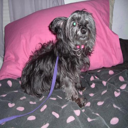

In [19]:
dog_images[0]

# Show some dogs and cats!

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

Use `imshow` function from matplotlib: https://matplotlib.org/3.1.3/api/_as_gen/matplotlib.pyplot.imshow.html

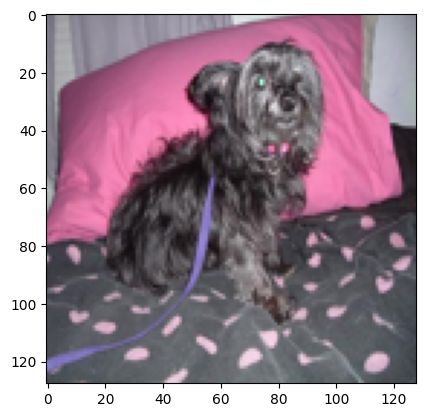

In [21]:
plt.imshow(dog_images[0])

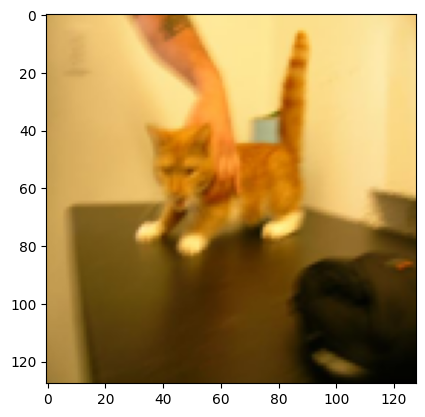

In [22]:
plt.imshow(cat_images[0])

# Simple nearest neighbor classification
We will split our dataset to training set and test set.  
Our model with predict if a test image is of cat or dog based on **a label of the closest image.**  

![nn](https://cdn-images-1.medium.com/max/800/0*uNbO79MrS7jvY4qp.png)

We'll measure **image similarity** as a simple mean **absolute distance between pixel values**.  

\begin{equation}
D(x_{train}, x_{test}) = \frac{1}{|pixels|}\sum_{pixels}{|x_{train}^{pixel} - x_{test}^{pixel}|}
\end{equation}

Nearest neighbors:  
**Training data:** ($x_{train}^i$), corresponding labels $y_{train}^i$  
**Test example:** $x_{test}$. We want to find a prediction for the test example $y_{pred}$.  
**Algorithm**:  
$j= \underset{x}{\mathrm{argmin}} D(x_{train}, x_{test})$  
$y_{pred} = y_{train}^{j}$


In [25]:
# img1, img2 - 2 images of the same size
# Return mean absolute distance
def image_dist(img1, img2):
    H, W, C = img1.shape #height, width
    distance = 0.
    for i in range(H):
        for j in range(W):
            for c in range(C):
                distance += np.abs(img1[i,j,c] - img2[i,j,c])
    distance = distance / (H * W * C)
    return distance

**^ Don't do this! NumPy is optimized for vectorized operations**

In [29]:
# img1, img2 - 2 images of the same size
def image_dist_vectorized(img1, img2):
    ## TODO - write a vectorized version
    distance = np.abs(img1-img2).mean() #a matrix, but more efficient implementation

    return distance

In [33]:
img1 = np.array(dog_images[0]).astype(np.float32)
img2 = np.array(dog_images[1]).astype(np.float32)

In [31]:
%timeit -n 10 image_dist(img1, img2)

96.6 ms ± 24.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [34]:
%timeit -n 10 image_dist_vectorized(img1, img2)

The slowest run took 6.37 times longer than the fastest. This could mean that an intermediate result is being cached.
95.2 µs ± 84 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Prepare the dataset
We need train images, test images, and labels

In [35]:
dog_images = np.array(dog_images).astype(np.float32)
cat_images = np.array(cat_images).astype(np.float32)
print(dog_images.shape, cat_images.shape)

# 4D Tensor of images: NxHxWxC
# N - number of images
# H - height
# W - width
# C - number of channels (RGB)
# (N, H, W, C)

(1200, 128, 128, 3) (1200, 128, 128, 3)


In [36]:
n_train = 1100 # 1100 out of 1200 for training, rest for test
dog_train = dog_images[:n_train]
cat_train = cat_images[:n_train]

dog_test = dog_images[n_train:]
cat_test = cat_images[n_train:]

x_train = np.concatenate((dog_train, cat_train), axis=0)
x_test = np.concatenate((dog_test, cat_test), axis=0)

y_train = ['dog' for i in range(len(dog_train))]
y_train.extend(['cat' for i in range(len(cat_train))])

y_test = ['dog' for i in range(len(dog_test))]
y_test.extend(['cat' for i in range(len(cat_test))])

In [37]:
print('Training set x_train shape: {}, y_train: {}'.format(x_train.shape, len(y_train)))
print('Test set x_test shape: {}, y_test: {}'.format(x_test.shape, len(y_test)))
print('Number of dogs in training set: {}'.format(np.sum(np.array(y_train)=='dog')))

Training set x_train shape: (2200, 128, 128, 3), y_train: 2200
Test set x_test shape: (200, 128, 128, 3), y_test: 200
Number of dogs in training set: 1100


In [38]:
class NNClassifier:

    def __init__(self):
        self.images = None
        self.labels = None

    def train(self, images, labels):
        # TODO - write a training method for NN Classifier (lazy classifier - just saving the data)



    def predict(self, image):
        # TODO - Find the closest image, distance to it and its label


        return predicted_label, min_distance, closest_image

In [44]:
class NNClassifierVectorized:

    def __init__(self):
        self.images = None
        self.labels = None

    def train(self, images, labels):
        # TODO - write a training method for NN Classifier (lazy classifier - just saving the data)
        self.images=images
        self.labels=labels

    def predict(self, image):
        # TODO - write a vectorized method without any for loops

        # self.images [N, H, W, C]
        # image [N, H, W, C]
        #find the nearest neighbour, that will be the predicted label
        distances = np.abs(self.images - image).mean(axis=(1,2,3)) #axis 0 is for the samples
        min_dist_index= np.argmin(distances)

        predicted_label = self.labels[min_dist_index]
        min_distance = distances[min_dist_index]
        closest_image=self.images[min_dist_index]


        return predicted_label, min_distance, closest_image

In [45]:
classifier = NNClassifierVectorized()
classifier.train(x_train, y_train)

# Classify an image!

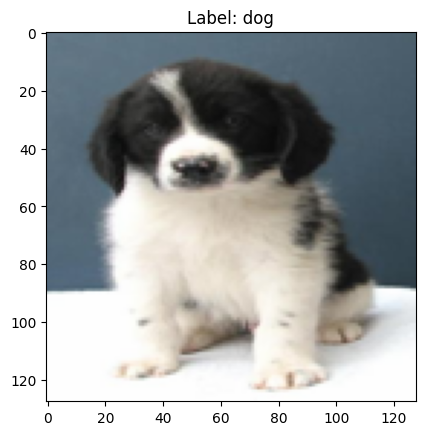

In [46]:
test_ind = 0
plt.imshow(x_test[test_ind] / 256)
plt.title('Label: {}'.format(y_test[test_ind]));

In [47]:
pred_label, min_dist, closest_image = classifier.predict(x_test[test_ind])

Predicted label: cat
Distance: 44.58799362182617


Text(0.5, 1.0, 'Closest image found')

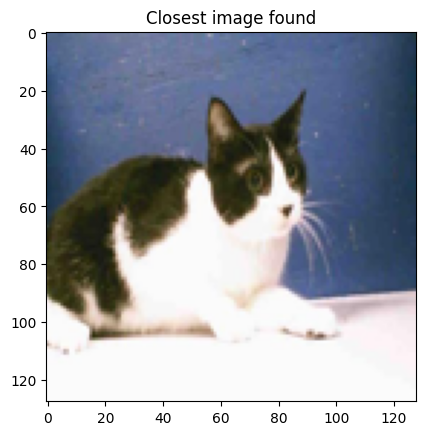

In [48]:
print('Predicted label: {}'.format(pred_label))
print('Distance: {}'.format(min_dist))
plt.imshow(closest_image / 256)
plt.title('Closest image found')

# Evaluate accuracy
How many dogs and cats from test set are classified correctly?

In [49]:
# TODO Run prediction on the entire test set x_test
#      Compute accuracy using predicted labels and true labels y_test
predicted_labels =[classifier.predict(img)[0] for img in x_test ]

In [50]:
predicted_labels[:10]

['cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'dog', 'cat', 'dog', 'cat']

In [ ]:
# TODO Write the predictions to predicted_labels list


In [53]:
y_test = np.array(y_test)
predicted_labels = np.array(predicted_labels)

In [54]:
#TODO compute accuracy
accuracy= (y_test == predicted_labels).mean()
print('Accuracy: {}%'.format(accuracy*100))

Accuracy: 59.5%
